# **Comparative Analysis of Linear and Nonlinear Regression Models for Building Energy Efficiency Prediction**


---

Ihsan saifulloh Adinata <br>
21/480763/TK/53052 <br>

## 1.**Description Project**



---


---


**This project analyzes the Energy Efficiency dataset, which contains 768 samples generated from computational simulations of building energy performance based on variations in building shape, orientation, and glazing configuration. Each sample includes eight numerical input features and two continuous targets, Heating Load and Cooling Load, making the dataset suitable for regression analysis. The study first applies linear regression models, Lasso, Ridge, and Elastic Net, evaluated using MSE, MAE, and R2, with the regularization parameter alpha optimized through grid search over a wide logarithmic range. Results show nearly identical performance across all linear models, indicating a performance ceiling under linear assumptions and limited impact from regularization choice. Non linear models then demonstrate clear improvements, with SVR and KNN outperforming linear approaches, confirming that the dataset structure is better captured by non linear regression methods.**

## 2.**Dataset**



---


---



The Energy Efficiency dataset contains results from computational simulations of building energy performance. The data is generated from 12 base building shapes combined with design parameters such as orientation and glazing configuration, producing 768 samples. Each sample includes 8 numerical input features and two numerical targets representing heating load and cooling load. The dataset fits regression analysis focused on understanding input output relationships from a data engineering perspective.

In [ ]:
!pip install ucimlrepo


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from ucimlrepo import fetch_ucirepo
import time

In [ ]:

energy_efficiency = fetch_ucirepo(id=242)


X = energy_efficiency.data.features
y = energy_efficiency.data.targets


print(energy_efficiency.metadata)
print(energy_efficiency.variables)

{'uci_id': 242, 'name': 'Energy Efficiency', 'repository_url': 'https://archive.ics.uci.edu/dataset/242/energy+efficiency', 'data_url': 'https://archive.ics.uci.edu/static/public/242/data.csv', 'abstract': 'This study looked into assessing the heating load and cooling load requirements of buildings (that is, energy efficiency) as a function of building parameters.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 768, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y1', 'Y2'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C51307', 'creators': ['Athanasios Tsanas', 'Angeliki Xifara'], 'intro_paper': {'ID': 379, 'type': 'NATIVE', 'title': 'Accurate quantitative estimation of energy performance of residential buildings using statistical machine 

## 2.**PreProcessing Dataset**


---


---




### 2.1 Normalize Dataset


---



Normalizing the data helps reduce skewness and stabilizes variance across features. This step improves model training since many regression algorithms assume symmetric input distributions. Normal distribution also makes feature influence easier to compare and interpret during analysis.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 2.2 Feature Engineering using Correlation Matrix


---



Feature engineering using a correlation matrix focuses on measuring linear relationships between features and targets. High correlation with the target indicates strong predictive relevance. Strong correlation between input features signals redundant information. Removing redundant features improves model stability and interpretability.

Matriks Korelasi Feature dan Y1(heating Load)
              X1            X2            X3            X4            X5  \
X1  1.000000e+00 -9.919015e-01 -2.037817e-01 -8.688234e-01  8.277473e-01   
X2 -9.919015e-01  1.000000e+00  1.955016e-01  8.807195e-01 -8.581477e-01   
X3 -2.037817e-01  1.955016e-01  1.000000e+00 -2.923165e-01  2.809757e-01   
X4 -8.688234e-01  8.807195e-01 -2.923165e-01  1.000000e+00 -9.725122e-01   
X5  8.277473e-01 -8.581477e-01  2.809757e-01 -9.725122e-01  1.000000e+00   
X6  4.678592e-17 -3.459372e-17 -2.429499e-17 -5.830058e-17  4.492205e-17   
X7 -2.960552e-15  3.636925e-15 -8.567455e-17 -1.759011e-15  1.489134e-17   
X8 -7.107006e-16  2.438409e-15  2.067384e-16 -1.078071e-15 -2.920613e-17   
Y1  6.222722e-01 -6.581202e-01  4.556712e-01 -8.618283e-01  8.894307e-01   

              X6            X7            X8        Y1  
X1  4.678592e-17 -2.960552e-15 -7.107006e-16  0.622272  
X2 -3.459372e-17  3.636925e-15  2.438409e-15 -0.658120  
X3 -2.429499e-17 -8.56

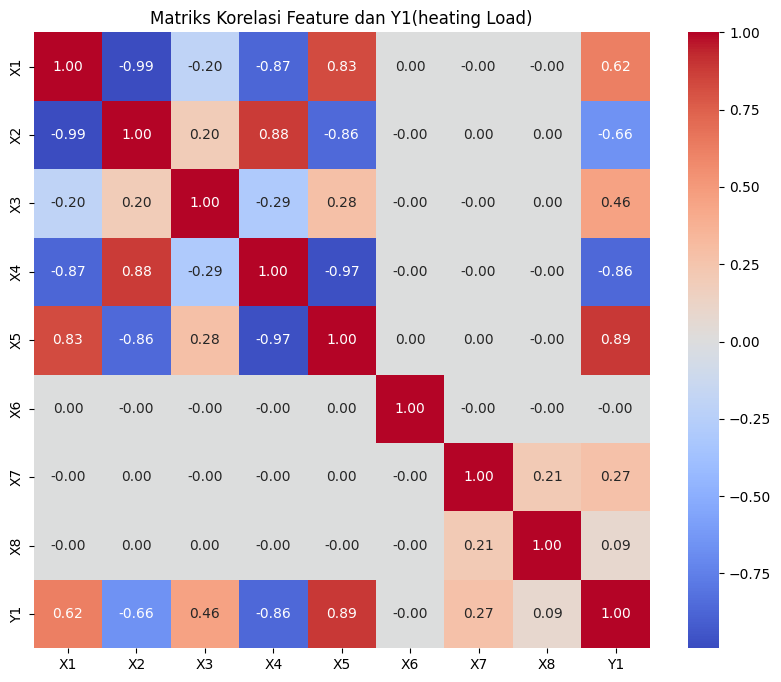

In [ ]:
# DataFrame feature dan target
df_X = pd.DataFrame(X, columns=X.columns)
df_y = pd.DataFrame(y, columns=y.columns)

# Matriks korelasi Feature + Y1
df_y1 = pd.concat([df_X, df_y[['Y1']]], axis=1)
corr_matrix_y1 = df_y1.corr()

# Matriks korelasi Feature + Y2
df_y2 = pd.concat([df_X, df_y[['Y2']]], axis=1)
corr_matrix_y2 = df_y2.corr()

print("Matriks Korelasi Feature dan Y1(heating Load)")
print(corr_matrix_y1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_y1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Matriks Korelasi Feature dan Y1(heating Load)")
plt.show()


**X1** and **X5** were selected because both **show strong correlation with the target Y1** while carrying complementary information. **X2** and **X4** also correlate strongly with Y1, **but they are highly correlated with other input** features, which **indicates redundancy**. X1 and X5 capture the relationship with Y1 without duplicating the same linear patterns seen in X2 and X4. This selection reduces multicollinearity and supports a more stable and interpretable regression model.

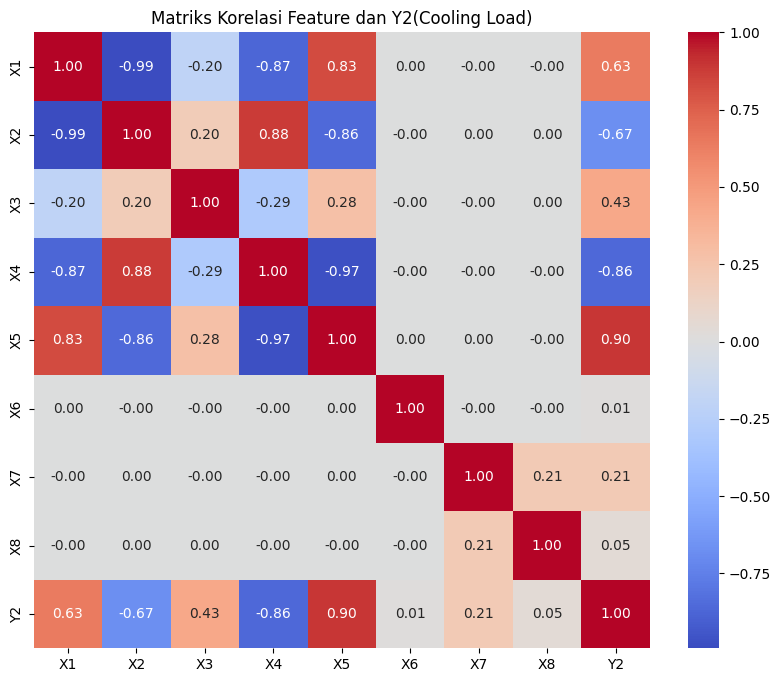


Matriks Korelasi Feature dan Y2(Cooling Load)
              X1            X2            X3            X4            X5  \
X1  1.000000e+00 -9.919015e-01 -2.037817e-01 -8.688234e-01  8.277473e-01   
X2 -9.919015e-01  1.000000e+00  1.955016e-01  8.807195e-01 -8.581477e-01   
X3 -2.037817e-01  1.955016e-01  1.000000e+00 -2.923165e-01  2.809757e-01   
X4 -8.688234e-01  8.807195e-01 -2.923165e-01  1.000000e+00 -9.725122e-01   
X5  8.277473e-01 -8.581477e-01  2.809757e-01 -9.725122e-01  1.000000e+00   
X6  4.678592e-17 -3.459372e-17 -2.429499e-17 -5.830058e-17  4.492205e-17   
X7 -2.960552e-15  3.636925e-15 -8.567455e-17 -1.759011e-15  1.489134e-17   
X8 -7.107006e-16  2.438409e-15  2.067384e-16 -1.078071e-15 -2.920613e-17   
Y2  6.343391e-01 -6.729989e-01  4.271170e-01 -8.625466e-01  8.957852e-01   

              X6            X7            X8        Y2  
X1  4.678592e-17 -2.960552e-15 -7.107006e-16  0.634339  
X2 -3.459372e-17  3.636925e-15  2.438409e-15 -0.672999  
X3 -2.429499e-17 -8.5

In [ ]:

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_y2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Matriks Korelasi Feature dan Y2(Cooling Load)")
plt.show()

print("\nMatriks Korelasi Feature dan Y2(Cooling Load)")
print(corr_matrix_y2)



A similar pattern appears in the correlation matrix for Y2. X1 and X5 again show strong correlation with the target while avoiding excessive correlation with each other. X2 and X4 display high correlation with Y2 but also exhibit strong linear dependency with other input features, which indicates redundancy. Based on the same reasoning, X1 and X5 are selected to preserve predictive strength while limiting multicollinearity.

In [ ]:
# Pilih fitur X1 dan X5 tanpa scaling
X_selected = X[['X1', 'X5']].values

### 2.2 Split Data (80% Training, 20% Testing) and 5-fold Cross-Validation

The data is split into 80 percent for training and 20 percent for testing to evaluate generalization performance. A 5 fold cross validation scheme is applied on the training set to ensure stable and reliable model evaluation. This approach reduces variance caused by a single train test split.

In [ ]:

X_selected = X[['X1', 'X5']].values

# Split Heating Load
X_train_h, X_test_h, y_train_heating, y_test_heating = train_test_split(
    X_selected,
    y['Y1'],
    test_size=0.2,
    random_state=42
)

# Split Cooling Load
X_train_c, X_test_c, y_train_cooling, y_test_cooling = train_test_split(
    X_selected,
    y['Y2'],
    test_size=0.2,
    random_state=0
)

def cross_val(model, X_train, y_train):
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    return np.mean(scores)

## 3.**Model Regresi Linear Dan Non-linear**



---



---



### 3.1 Linear Regression Model


---



The dataset is processed using three linear regression models, **Lasso, Ridge, and Elastic Net**. Model performance is evaluated using MSE, MAE, and R2 metrics to measure prediction error and fit quality. The regularization parameter alpha is selected through grid search across a logarithmic range from 1e-10 to 1e10. This procedure enables a consistent comparison of linear model behavior under different regularization strengths.

#### 3.1.1 Tuning Parameter Dengan Grid Search

---



In [ ]:
param_grid = {'alpha': np.logspace(-10, 10, 101)}

# ===== Heating Load =====

start_time = time.time()
lasso_grid_heating = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid_heating.fit(X_train_h, y_train_heating)
lasso_time_heating = time.time() - start_time
best_lasso_lambda_heating = lasso_grid_heating.best_params_['alpha']

start_time = time.time()
ridge_grid_heating = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid_heating.fit(X_train_h, y_train_heating)
ridge_time_heating = time.time() - start_time
best_ridge_lambda_heating = ridge_grid_heating.best_params_['alpha']

elastic_net_param_grid = {
    'alpha': np.logspace(-4, 4, 100),
    'l1_ratio': np.linspace(0.1, 1, 10)
}

start_time = time.time()
elastic_net_grid_heating = GridSearchCV(
    ElasticNet(),
    elastic_net_param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)
elastic_net_grid_heating.fit(X_train_h, y_train_heating)
elastic_net_time_heating = time.time() - start_time
best_elastic_net_params_heating = elastic_net_grid_heating.best_params_

print("Heating Load")
print("Best Lasso alpha:", best_lasso_lambda_heating, "Time:", round(lasso_time_heating, 2), "seconds")
print("Best Ridge alpha:", best_ridge_lambda_heating, "Time:", round(ridge_time_heating, 2), "seconds")
print("Best ElasticNet params:", best_elastic_net_params_heating, "Time:", round(elastic_net_time_heating, 2), "seconds")

# ===== Cooling Load =====

start_time = time.time()
lasso_grid_cooling = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid_cooling.fit(X_train_c, y_train_cooling)
lasso_time_cooling = time.time() - start_time
best_lasso_lambda_cooling = lasso_grid_cooling.best_params_['alpha']

start_time = time.time()
ridge_grid_cooling = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid_cooling.fit(X_train_c, y_train_cooling)
ridge_time_cooling = time.time() - start_time
best_ridge_lambda_cooling = ridge_grid_cooling.best_params_['alpha']

start_time = time.time()
elastic_net_grid_cooling = GridSearchCV(
    ElasticNet(),
    elastic_net_param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)
elastic_net_grid_cooling.fit(X_train_c, y_train_cooling)
elastic_net_time_cooling = time.time() - start_time
best_elastic_net_params_cooling = elastic_net_grid_cooling.best_params_

print("\nCooling Load")
print("Best Lasso alpha:", best_lasso_lambda_cooling, "Time:", round(lasso_time_cooling, 2), "seconds")
print("Best Ridge alpha:", best_ridge_lambda_cooling, "Time:", round(ridge_time_cooling, 2), "seconds")
print("Best ElasticNet params:", best_elastic_net_params_cooling, "Time:", round(elastic_net_time_cooling, 2), "seconds")

Heating Load
Best Lasso alpha: 1e-10 Time: 1.32 seconds
Best Ridge alpha: 0.006309573444801942 Time: 1.43 seconds
Best ElasticNet params: {'alpha': np.float64(0.0001), 'l1_ratio': np.float64(0.9)} Time: 22.24 seconds

Cooling Load
Best Lasso alpha: 1e-10 Time: 1.13 seconds
Best Ridge alpha: 1e-10 Time: 1.13 seconds
Best ElasticNet params: {'alpha': np.float64(0.0001), 'l1_ratio': np.float64(1.0)} Time: 12.35 seconds


Grid search shows optimal alpha values clustered near zero for both Heating Load and Cooling Load. This pattern indicates weak regularization needs and similar behavior across linear models. The result reinforces limited benefit from linear regularization for this dataset.

#### 3.1.2 Evaluate Value Of Model With Best Parameter


---





In [ ]:


# Function to evaluate model performance
def evaluate_model(model_name, model_pred, y_true):
    mse = mean_squared_error(y_true, model_pred)
    mae = mean_absolute_error(y_true, model_pred)
    r2 = r2_score(y_true, model_pred)
    print(model_name, "Evaluation:")
    print("  MSE:", round(mse, 4))
    print("  MAE:", round(mae, 4))
    print("  R2:", round(r2, 4))
    print("-" * 30)
    return mse, mae, r2


# ===== Heating Load (Y1) with best params =====

lasso_best_heating = Lasso(alpha=best_lasso_lambda_heating)
ridge_best_heating = Ridge(alpha=best_ridge_lambda_heating)
elastic_best_heating = ElasticNet(
    alpha=best_elastic_net_params_heating["alpha"],
    l1_ratio=best_elastic_net_params_heating["l1_ratio"]
)

lasso_best_heating.fit(X_train_h, y_train_heating)
lasso_best_pred_heating = lasso_best_heating.predict(X_test_h)

ridge_best_heating.fit(X_train_h, y_train_heating)
ridge_best_pred_heating = ridge_best_heating.predict(X_test_h)

elastic_best_heating.fit(X_train_h, y_train_heating)
elastic_best_pred_heating = elastic_best_heating.predict(X_test_h)

# ===== Cooling Load (Y2) with best params =====

lasso_best_cooling = Lasso(alpha=best_lasso_lambda_cooling)
ridge_best_cooling = Ridge(alpha=best_ridge_lambda_cooling)
elastic_best_cooling = ElasticNet(
    alpha=best_elastic_net_params_cooling["alpha"],
    l1_ratio=best_elastic_net_params_cooling["l1_ratio"]
)

lasso_best_cooling.fit(X_train_c, y_train_cooling)
lasso_best_pred_cooling = lasso_best_cooling.predict(X_test_c)

ridge_best_cooling.fit(X_train_c, y_train_cooling)
ridge_best_pred_cooling = ridge_best_cooling.predict(X_test_c)

elastic_best_cooling.fit(X_train_c, y_train_cooling)
elastic_best_pred_cooling = elastic_best_cooling.predict(X_test_c)


In [ ]:
# ===== Heating Load (Y1) Best Params =====

heating_results_best = {
    "Model": ["Lasso (Best)", "Ridge (Best)", "ElasticNet (Best)"],
    "MSE": [
        mean_squared_error(y_test_heating, lasso_best_pred_heating),
        mean_squared_error(y_test_heating, ridge_best_pred_heating),
        mean_squared_error(y_test_heating, elastic_best_pred_heating)
    ],
    "MAE": [
        mean_absolute_error(y_test_heating, lasso_best_pred_heating),
        mean_absolute_error(y_test_heating, ridge_best_pred_heating),
        mean_absolute_error(y_test_heating, elastic_best_pred_heating)
    ],
    "R2": [
        r2_score(y_test_heating, lasso_best_pred_heating),
        r2_score(y_test_heating, ridge_best_pred_heating),
        r2_score(y_test_heating, elastic_best_pred_heating)
    ]
}

df_heating_results_best = pd.DataFrame(heating_results_best)
print("Heating Load Model Performance (Best Params)")
print(df_heating_results_best.round(4))


# ===== Cooling Load (Y2) Best Params =====

cooling_results_best = {
    "Model": ["Lasso (Best)", "Ridge (Best)", "ElasticNet (Best)"],
    "MSE": [
        mean_squared_error(y_test_cooling, lasso_best_pred_cooling),
        mean_squared_error(y_test_cooling, ridge_best_pred_cooling),
        mean_squared_error(y_test_cooling, elastic_best_pred_cooling)
    ],
    "MAE": [
        mean_absolute_error(y_test_cooling, lasso_best_pred_cooling),
        mean_absolute_error(y_test_cooling, ridge_best_pred_cooling),
        mean_absolute_error(y_test_cooling, elastic_best_pred_cooling)
    ],
    "R2": [
        r2_score(y_test_cooling, lasso_best_pred_cooling),
        r2_score(y_test_cooling, ridge_best_pred_cooling),
        r2_score(y_test_cooling, elastic_best_pred_cooling)
    ]
}

df_cooling_results_best = pd.DataFrame(cooling_results_best)
print("\nCooling Load Model Performance (Best Params)")
print(df_cooling_results_best.round(8))

Heating Load Model Performance (Best Params)
               Model      MSE    MAE      R2
0       Lasso (Best)  16.4319  3.079  0.8424
1       Ridge (Best)  16.4344  3.079  0.8423
2  ElasticNet (Best)  16.4351  3.079  0.8423

Cooling Load Model Performance (Best Params)
               Model        MSE       MAE        R2
0       Lasso (Best)  14.409402  2.835688  0.846799
1       Ridge (Best)  14.409402  2.835688  0.846799
2  ElasticNet (Best)  14.409802  2.835583  0.846795


Both Heating Load and Cooling Load show nearly identical performance across Lasso, Ridge, and ElasticNet, with minimal differences in MSE, MAE, and R2. Similar results across regularization methods signal limited impact from penalty choice and point to a performance ceiling for linear assumptions. **This pattern suggests linear models do not fit the dataset structure well. Testing non linear models becomes a necessary next step to capture more complex relationships.**

#### 3.1.3 Plotting Predictions Model


---



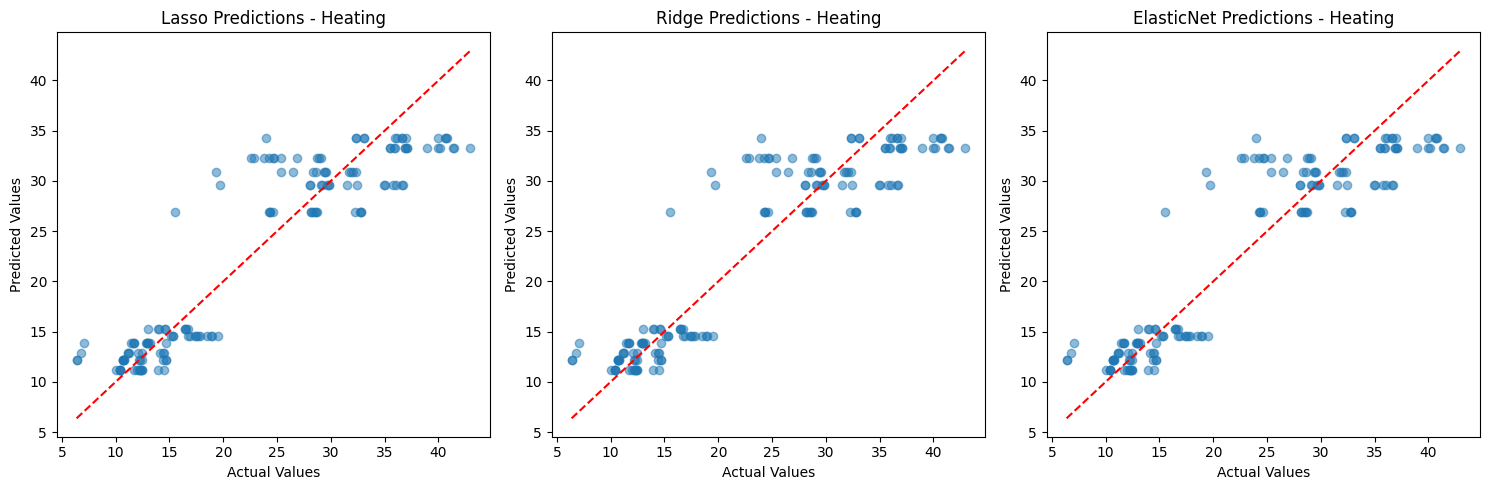

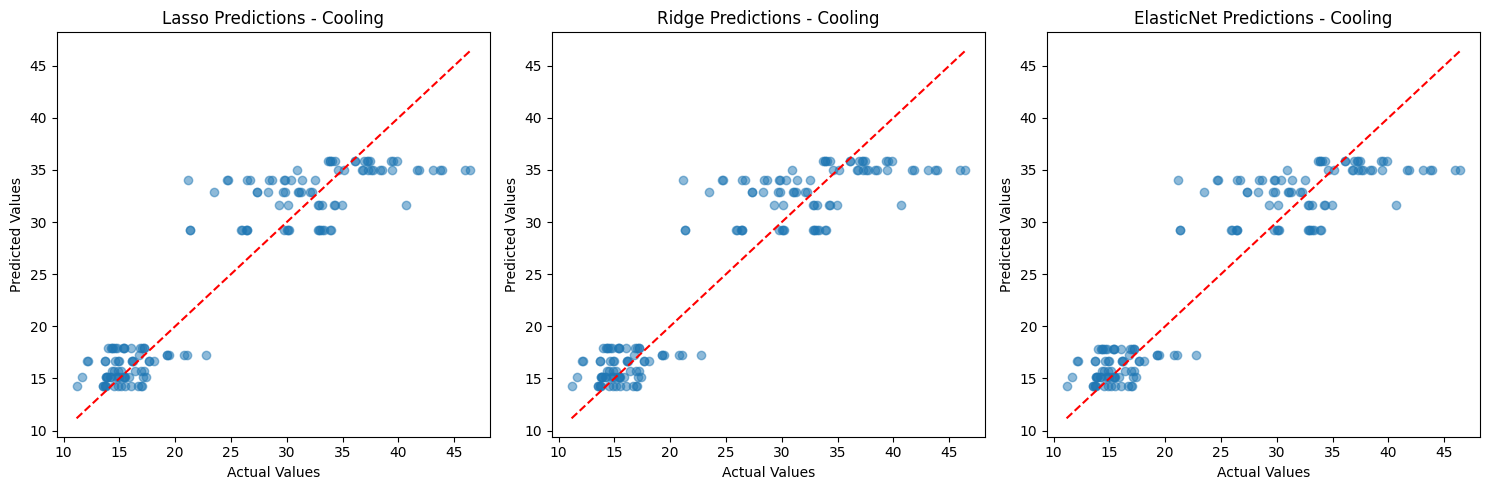

In [ ]:
# Plotting untuk Heating Load (Y1)

models_linear_heating = {
    "Lasso": lasso_best_pred_heating,
    "Ridge": ridge_best_pred_heating,
    "ElasticNet": elastic_best_pred_heating
}

plt.figure(figsize=(15, 5))

for i, (name, y_pred) in enumerate(models_linear_heating.items(), 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test_heating, y_pred, alpha=0.5)
    plt.plot(
        [y_test_heating.min(), y_test_heating.max()],
        [y_test_heating.min(), y_test_heating.max()],
        "r--"
    )
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(name + " Predictions - Heating")

plt.tight_layout()
plt.show()


# Plotting untuk Cooling Load (Y2)

models_linear_cooling = {
    "Lasso": lasso_best_pred_cooling,
    "Ridge": ridge_best_pred_cooling,
    "ElasticNet": elastic_best_pred_cooling
}

plt.figure(figsize=(15, 5))

for i, (name, y_pred) in enumerate(models_linear_cooling.items(), 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test_cooling, y_pred, alpha=0.5)
    plt.plot(
        [y_test_cooling.min(), y_test_cooling.max()],
        [y_test_cooling.min(), y_test_cooling.max()],
        "r--"
    )
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(name + " Predictions - Cooling")

plt.tight_layout()
plt.show()


#### 3.1.4 Conclution On Linear Regression Model


---



Both Heating Load and Cooling Load show nearly identical performance across Lasso, Ridge, and ElasticNet, with minimal differences in MSE, MAE, and R2. **Similar results across regularization methods signal limited impact from penalty choice and point to a performance ceiling for linear assumptions. This pattern suggests linear models do not fit the dataset structure well.**

### 3.2. Non-Linear Regression Model


Nonlinear models are applied to capture relationships not represented by linear assumptions. Polynomial regression extends linear regression by introducing interaction and higher order terms. Support Vector Regression uses kernel functions to model complex patterns in feature space. KNN regression predicts values based on local neighborhood similarity, which allows flexible, data driven behavior.

In [ ]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Function to evaluate model performance
def evaluate_model(model_name, model_pred, y_true):
    mse = mean_squared_error(y_true, model_pred)
    mae = mean_absolute_error(y_true, model_pred)
    r2 = r2_score(y_true, model_pred)
    print(model_name, "Evaluation:")
    print("  MSE:", round(mse, 4))
    print("  MAE:", round(mae, 4))
    print("  R2:", round(r2, 4))
    print("-" * 30)
    return mse, mae, r2

In [ ]:
# Prompt 1: Model non linear (SVR, KNN, Polynomial Regression)
svr_model = SVR(kernel="rbf")
knn_model = KNeighborsRegressor()

poly_ridge_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge", Ridge())
])


### 3.2.1 Tuning Parameter



---



The alpha grid controls regularization strength for linear and polynomial Ridge models across a wide logarithmic range. In SVR, parameter C adjusts model flexibility while gamma controls kernel sensitivity to data distance. For KNN, n_neighbors defines neighborhood size and weights determine equal or distance based influence. Polynomial Ridge tuning combines polynomial degree for non linear expansion and alpha for controlling model complexity.

In [ ]:


param_grid_alpha = {"alpha": np.logspace(-10, 10, 101)}

svr_param_grid = {
    "C": np.logspace(-4, 4, 11),
    "gamma": np.logspace(-4, 4, 11)
}

knn_param_grid = {
    "n_neighbors": list(range(1, 11)),
    "weights": ["uniform", "distance"]
}

poly_ridge_param_grid = {
    "poly__degree": [2, 5],
    "ridge__alpha": param_grid_alpha["alpha"]
}

# Heating (Y1)
svr_grid_heating = GridSearchCV(svr_model, svr_param_grid, cv=5, scoring="neg_mean_squared_error")
svr_grid_heating.fit(X_train_h, y_train_heating)
best_svr_heating = svr_grid_heating.best_estimator_

knn_grid_heating = GridSearchCV(knn_model, knn_param_grid, cv=5, scoring="neg_mean_squared_error")
knn_grid_heating.fit(X_train_h, y_train_heating)
best_knn_heating = knn_grid_heating.best_estimator_

poly_ridge_grid_heating = GridSearchCV(poly_ridge_model, poly_ridge_param_grid, cv=5, scoring="neg_mean_squared_error")
poly_ridge_grid_heating.fit(X_train_h, y_train_heating)
best_poly_ridge_heating = poly_ridge_grid_heating.best_estimator_

print("Best SVR params - Heating:", svr_grid_heating.best_params_)
print("Best KNN params - Heating:", knn_grid_heating.best_params_)
print("Best Poly Ridge params - Heating:", poly_ridge_grid_heating.best_params_)

# Cooling (Y2)
svr_grid_cooling = GridSearchCV(svr_model, svr_param_grid, cv=5, scoring="neg_mean_squared_error")
svr_grid_cooling.fit(X_train_c, y_train_cooling)
best_svr_cooling = svr_grid_cooling.best_estimator_

knn_grid_cooling = GridSearchCV(knn_model, knn_param_grid, cv=5, scoring="neg_mean_squared_error")
knn_grid_cooling.fit(X_train_c, y_train_cooling)
best_knn_cooling = knn_grid_cooling.best_estimator_

poly_ridge_grid_cooling = GridSearchCV(poly_ridge_model, poly_ridge_param_grid, cv=5, scoring="neg_mean_squared_error")
poly_ridge_grid_cooling.fit(X_train_c, y_train_cooling)
best_poly_ridge_cooling = poly_ridge_grid_cooling.best_estimator_

print("Best SVR params - Cooling:", svr_grid_cooling.best_params_)
print("Best KNN params - Cooling:", knn_grid_cooling.best_params_)
print("Best Poly Ridge params - Cooling:", poly_ridge_grid_cooling.best_params_)


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.21933e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.8882e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.88387e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.013e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.61505e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.

Best SVR params - Heating: {'C': np.float64(6.309573444801943), 'gamma': np.float64(10000.0)}
Best KNN params - Heating: {'n_neighbors': 10, 'weights': 'uniform'}
Best Poly Ridge params - Heating: {'poly__degree': 5, 'ridge__alpha': np.float64(1e-10)}


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.17105e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.46887e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.49404e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.85103e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.19655e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

Best SVR params - Cooling: {'C': np.float64(1584.893192461114), 'gamma': np.float64(251.18864315095823)}
Best KNN params - Cooling: {'n_neighbors': 10, 'weights': 'uniform'}
Best Poly Ridge params - Cooling: {'poly__degree': 5, 'ridge__alpha': np.float64(1e-10)}


The optimal SVR parameters show high C and gamma values, which indicates the model relies on strong flexibility to fit complex non linear patterns in Cooling Load. KNN selects the maximum number of neighbors with uniform weighting, which suggests smoother predictions and reduced sensitivity to local noise. Polynomial Ridge favors a higher polynomial degree with near zero regularization, which signals that non linear feature expansion improves fit while penalty strength plays a minor role.

In [ ]:
# Prompt 4: Evaluate model (fit, predict, table)

# Heating predictions
y_pred_svr_heating = best_svr_heating.predict(X_test_h)
y_pred_knn_heating = best_knn_heating.predict(X_test_h)
y_pred_poly_heating = best_poly_ridge_heating.predict(X_test_h)

# Cooling predictions
y_pred_svr_cooling = best_svr_cooling.predict(X_test_c)
y_pred_knn_cooling = best_knn_cooling.predict(X_test_c)
y_pred_poly_cooling = best_poly_ridge_cooling.predict(X_test_c)

# Evaluate Heating
evaluate_model("SVR (Best) - Heating", y_pred_svr_heating, y_test_heating)
evaluate_model("KNN (Best) - Heating", y_pred_knn_heating, y_test_heating)
evaluate_model("Polynomial Ridge (Best) - Heating", y_pred_poly_heating, y_test_heating)

# Evaluate Cooling
evaluate_model("SVR (Best) - Cooling", y_pred_svr_cooling, y_test_cooling)
evaluate_model("KNN (Best) - Cooling", y_pred_knn_cooling, y_test_cooling)
evaluate_model("Polynomial Ridge (Best) - Cooling", y_pred_poly_cooling, y_test_cooling)

# Tabel hasil Heating
df_heating_nonlinear = pd.DataFrame({
    "Model": ["SVR (Best)", "KNN (Best)", "Polynomial Ridge (Best)"],
    "MSE": [
        mean_squared_error(y_test_heating, y_pred_svr_heating),
        mean_squared_error(y_test_heating, y_pred_knn_heating),
        mean_squared_error(y_test_heating, y_pred_poly_heating)
    ],
    "MAE": [
        mean_absolute_error(y_test_heating, y_pred_svr_heating),
        mean_absolute_error(y_test_heating, y_pred_knn_heating),
        mean_absolute_error(y_test_heating, y_pred_poly_heating)
    ],
    "R2": [
        r2_score(y_test_heating, y_pred_svr_heating),
        r2_score(y_test_heating, y_pred_knn_heating),
        r2_score(y_test_heating, y_pred_poly_heating)
    ]
}).round(4)

print("\nNon Linear Performance - Heating")
print(df_heating_nonlinear)

# Tabel hasil Cooling
df_cooling_nonlinear = pd.DataFrame({
    "Model": ["SVR (Best)", "KNN (Best)", "Polynomial Ridge (Best)"],
    "MSE": [
        mean_squared_error(y_test_cooling, y_pred_svr_cooling),
        mean_squared_error(y_test_cooling, y_pred_knn_cooling),
        mean_squared_error(y_test_cooling, y_pred_poly_cooling)
    ],
    "MAE": [
        mean_absolute_error(y_test_cooling, y_pred_svr_cooling),
        mean_absolute_error(y_test_cooling, y_pred_knn_cooling),
        mean_absolute_error(y_test_cooling, y_pred_poly_cooling)
    ],
    "R2": [
        r2_score(y_test_cooling, y_pred_svr_cooling),
        r2_score(y_test_cooling, y_pred_knn_cooling),
        r2_score(y_test_cooling, y_pred_poly_cooling)
    ]
}).round(4)

print("\nNon Linear Performance - Cooling")
print(df_cooling_nonlinear)


SVR (Best) - Heating Evaluation:
  MSE: 9.5726
  MAE: 2.1826
  R2: 0.9082
------------------------------
KNN (Best) - Heating Evaluation:
  MSE: 10.2349
  MAE: 2.3807
  R2: 0.9018
------------------------------
Polynomial Ridge (Best) - Heating Evaluation:
  MSE: 12.1697
  MAE: 2.5982
  R2: 0.8832
------------------------------
SVR (Best) - Cooling Evaluation:
  MSE: 7.402
  MAE: 2.0274
  R2: 0.9213
------------------------------
KNN (Best) - Cooling Evaluation:
  MSE: 7.9987
  MAE: 2.1396
  R2: 0.915
------------------------------
Polynomial Ridge (Best) - Cooling Evaluation:
  MSE: 9.45
  MAE: 2.2585
  R2: 0.8995
------------------------------

Non Linear Performance - Heating
                     Model      MSE     MAE      R2
0               SVR (Best)   9.5726  2.1826  0.9082
1               KNN (Best)  10.2349  2.3807  0.9018
2  Polynomial Ridge (Best)  12.1697  2.5982  0.8832

Non Linear Performance - Cooling
                     Model     MSE     MAE      R2
0               SVR

### 3.1.4 Conclution On Non-Linear Regression Model


---



Non linear models show clear improvement over linear results for both Heating and Cooling Load. SVR achieves the lowest MSE and highest R2, followed by KNN, while Polynomial Ridge performs weaker but still above linear baselines. Error reduction and R2 gains indicate stronger ability to model complex relationships. These results support the conclusion that this dataset fits non linear regression methods better than linear approaches.

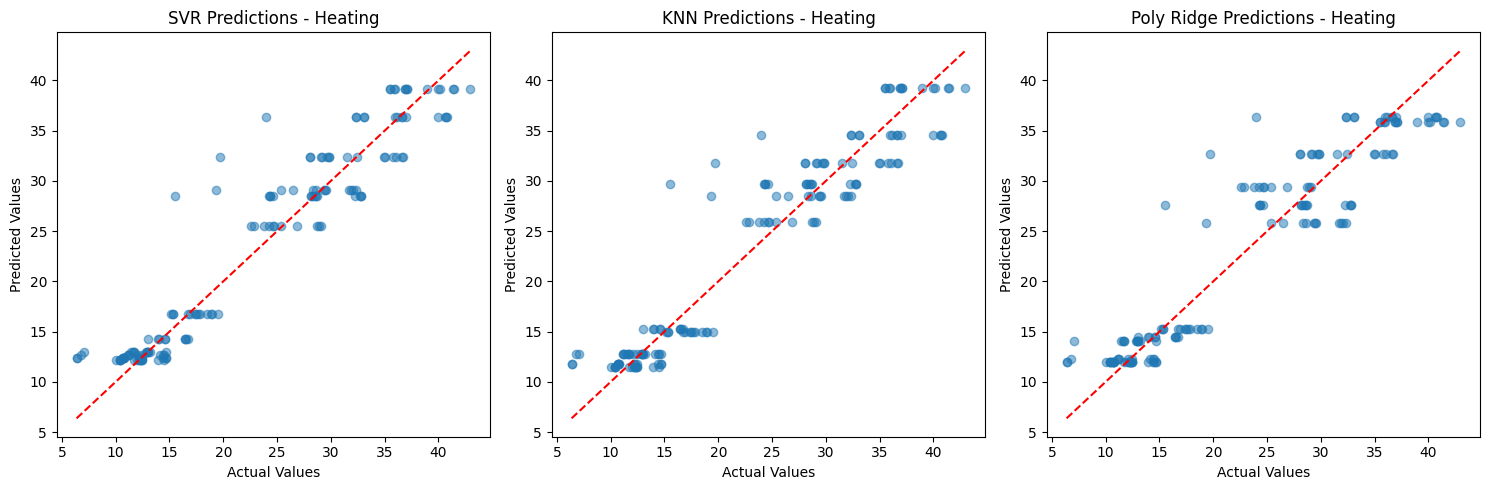

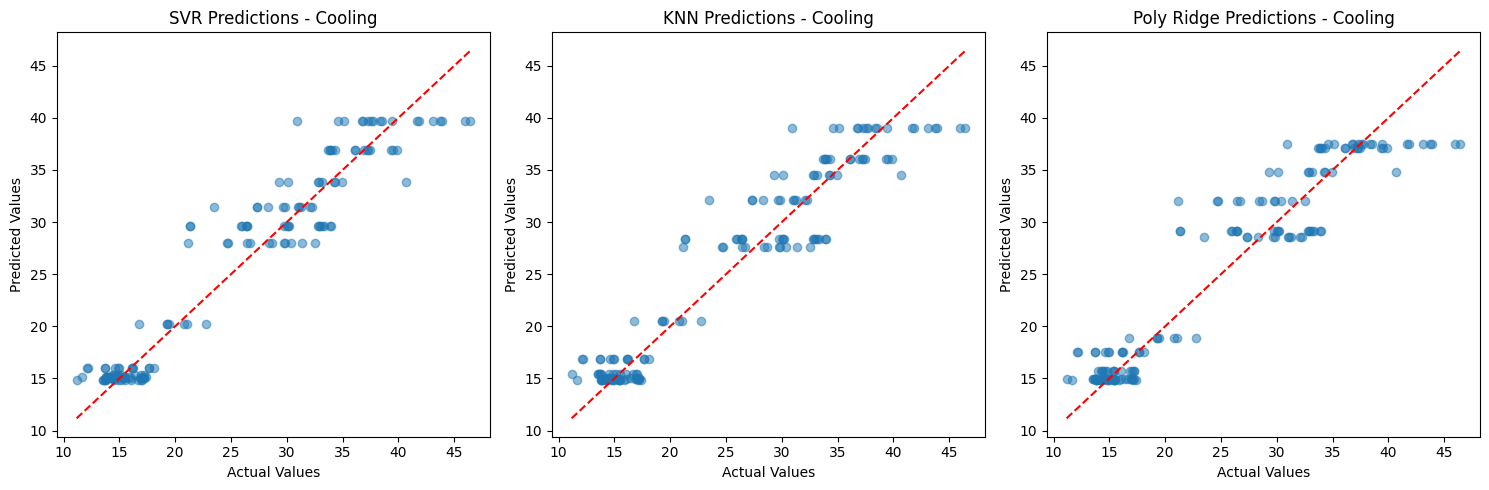

In [ ]:
# Prompt 3: Plotting hasil

models_nonlinear_heating = {
    "SVR": y_pred_svr_heating,
    "KNN": y_pred_knn_heating,
    "Poly Ridge": y_pred_poly_heating
}

plt.figure(figsize=(15, 5))

for i, (name, y_pred) in enumerate(models_nonlinear_heating.items(), 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test_heating, y_pred, alpha=0.5)
    plt.plot(
        [y_test_heating.min(), y_test_heating.max()],
        [y_test_heating.min(), y_test_heating.max()],
        "r--"
    )
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(name + " Predictions - Heating")

plt.tight_layout()
plt.show()

models_nonlinear_cooling = {
    "SVR": y_pred_svr_cooling,
    "KNN": y_pred_knn_cooling,
    "Poly Ridge": y_pred_poly_cooling
}

plt.figure(figsize=(15, 5))

for i, (name, y_pred) in enumerate(models_nonlinear_cooling.items(), 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test_cooling, y_pred, alpha=0.5)
    plt.plot(
        [y_test_cooling.min(), y_test_cooling.max()],
        [y_test_cooling.min(), y_test_cooling.max()],
        "r--"
    )
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(name + " Predictions - Cooling")

plt.tight_layout()
plt.show()


### 4.Conclution


---



Heating Load and Cooling Load show almost identical performance across Lasso, Ridge, and ElasticNet, with minimal differences in MSE, MAE, and R2. This consistency indicates a performance limit under linear assumptions and shows limited benefit from regularization choice. Non linear models deliver clear improvements, with SVR achieving the lowest errors and highest R2, followed by KNN, while Polynomial Ridge remains above linear results. These gains confirm the dataset aligns better with non linear regression methods.